In [2]:
import pandas as pd

df = pd.read_csv("India Agriculture Crop Production.csv")
df.head()

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345407 entries, 0 to 345406
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   State             345407 non-null  object 
 1   District          345407 non-null  object 
 2   Crop              345375 non-null  object 
 3   Year              345407 non-null  object 
 4   Season            345406 non-null  object 
 5   Area              345374 non-null  float64
 6   Area Units        345407 non-null  object 
 7   Production        340414 non-null  float64
 8   Production Units  345407 non-null  object 
 9   Yield             345374 non-null  float64
dtypes: float64(3), object(7)
memory usage: 26.4+ MB


In [4]:
df.isnull().sum()

,0
State,0
District,0
Crop,32
Year,0
Season,1
Area,33
Area Units,0
Production,4993
Production Units,0
Yield,33


In [5]:
df = df.dropna()
df.isnull().sum()

,0
State,0
District,0
Crop,0
Year,0
Season,0
Area,0
Area Units,0
Production,0
Production Units,0
Yield,0


In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

df.columns

Index(['state', 'district', 'crop', 'year', 'season', 'area', 'area_units',
       'production', 'production_units', 'yield'],
      dtype='object')

In [9]:
df.head()

,state,district,crop,year,season,area,area_units,production,production_units,yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296


In [10]:
df.to_csv("cleaned_agriculture_data.csv", index=False)

In [11]:
from google.colab import files
files.download("cleaned_agriculture_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
df['production'].sum()

np.float64(326242956201.299)

In [13]:
df['yield'].mean()

np.float64(80.56457679278033)

In [14]:
df['crop'].value_counts().head()

,count
crop,
Rice,21573
Maize,20329
Moong(Green Gram),14813
Urad,14389
Sesamum,12744


In [15]:
df.groupby('state')['production'].sum().sort_values(ascending=False).head()

,production
state,
Kerala,1.297006e+11
Tamil Nadu,7.805176e+10
Karnataka,6.377280e+10
Andhra Pradesh,2.607622e+10
West Bengal,8.941179e+09


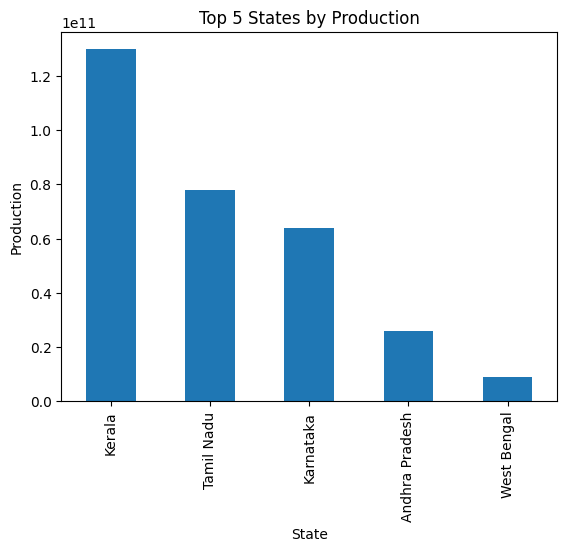

In [16]:
import matplotlib.pyplot as plt

top_states = df.groupby('state')['production'].sum().sort_values(ascending=False).head()

top_states.plot(kind='bar')

plt.title("Top 5 States by Production")
plt.xlabel("State")
plt.ylabel("Production")

plt.show()